# Progressive Dataset Training on CIFAR-10
## Models: MobileNetV2 & EfficientNet-B0

## Strategy: Train the model by progressively revealing more of the dataset:

Stage 1: 10% of training data (5,000 images)

Stage 2: 25% of training data (12,500 images)

Stage 3: 50% of training data (25,000 images)

Stage 4: 75% of training data (37,500 images)

Stage 5: 100% of training data (50,000 images)
Each stage trains for 5 epochs, totalling 25 epochs — same as the full dataset strategy.

## IMPORTS

In [ ]:
import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from torch.utils.data import Dataset, DataLoader

In [ ]:
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## DATASET

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Training:", x_train.shape)
print("Testing:", x_test.shape)

Training: (50000, 32, 32, 3)
Testing: (10000, 32, 32, 3)


In [ ]:
# Normalization
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
class CIFAR10Dataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32).permute(0,3,1,2)
        self.labels = torch.tensor(labels, dtype=torch.long).squeeze()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

## DATASET LOADER

In [ ]:
trainset = CIFAR10Dataset(x_train, y_train)
testset = CIFAR10Dataset(x_test, y_test)

trainloader_full = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

## LOSS FUNCTION

In [ ]:
criterion = nn.CrossEntropyLoss()

## PROGRESSIVE LOADER

In [ ]:
def get_progressive_loader(dataset, percentage):
    size = int(len(dataset) * percentage)
    subset = torch.utils.data.Subset(dataset, list(range(size)))
    return DataLoader(subset, batch_size=64, shuffle=True)

## TRAIN FUNCTION

In [ ]:
def train_progressive(model, dataset, testloader, optimizer, stages, epochs_per_stage):
    train_loss, train_acc = [], []
    val_loss, val_acc = [], []

    current_epoch = 0

    for p in stages:
        loader = get_progressive_loader(dataset, p)

        print(f"\n--- Training with {int(p*100)}% data ---")

        for _ in range(epochs_per_stage):

            model.train()
            running_loss, correct, total = 0, 0, 0

            for images, labels in loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                running_loss += loss.item()

                _, pred = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (pred == labels).sum().item()

            t_loss = running_loss / len(loader)
            t_acc = 100 * correct / total

            # VALIDATION
            model.eval()
            v_loss, v_correct, v_total = 0, 0, 0

            with torch.no_grad():
                for images, labels in testloader:
                    images, labels = images.to(device), labels.to(device)

                    outputs = model(images)
                    loss = criterion(outputs, labels)

                    v_loss += loss.item()

                    _, pred = torch.max(outputs, 1)
                    v_total += labels.size(0)
                    v_correct += (pred == labels).sum().item()

            v_loss /= len(testloader)
            v_acc = 100 * v_correct / v_total

            train_loss.append(t_loss)
            train_acc.append(t_acc)
            val_loss.append(v_loss)
            val_acc.append(v_acc)

            current_epoch += 1

            print(f"Epoch {current_epoch}: Train Acc={t_acc:.2f}% | Val Acc={v_acc:.2f}%")

    return train_loss, train_acc, val_loss, val_acc

## EVALUATE FUNCTION

In [ ]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, pred = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    return 100 * correct / total

## 1. MOBILE-NET

### MODEL

In [ ]:
model_mob = models.mobilenet_v2(weights="DEFAULT")
model_mob.classifier[1] = nn.Linear(1280, 10)
model_mob = model_mob.to(device)

optimizer_mob = optim.Adam(model_mob.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 172MB/s]


### TRAIN

In [ ]:
stages = [0.1, 0.25, 0.5, 0.75, 1.0]

loss_mob, acc_mob, val_loss_mob, val_acc_mob = train_progressive(
    model_mob, trainset, testloader, optimizer_mob,
    stages=stages, epochs_per_stage=2
)


--- Training with 10% data ---
Epoch 1: Train Acc=40.12% | Val Acc=55.09%
Epoch 2: Train Acc=60.24% | Val Acc=60.62%

--- Training with 25% data ---
Epoch 3: Train Acc=61.96% | Val Acc=66.00%
Epoch 4: Train Acc=71.29% | Val Acc=70.00%

--- Training with 50% data ---
Epoch 5: Train Acc=72.48% | Val Acc=73.60%
Epoch 6: Train Acc=77.29% | Val Acc=75.82%

--- Training with 75% data ---
Epoch 7: Train Acc=77.76% | Val Acc=77.98%
Epoch 8: Train Acc=81.11% | Val Acc=78.65%

--- Training with 100% data ---
Epoch 9: Train Acc=81.51% | Val Acc=80.03%
Epoch 10: Train Acc=83.39% | Val Acc=80.65%


### TEST ACCURACY

In [ ]:
acc_mob_test = evaluate(model_mob, testloader)
print("MobileNet Progressive Accuracy:", acc_mob_test)

MobileNet Progressive Accuracy: 80.65


### ACCURACY GRAPH

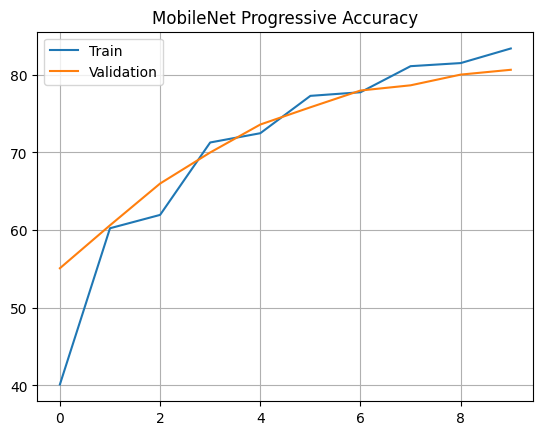

In [ ]:
plt.plot(acc_mob, label="Train")
plt.plot(val_acc_mob, label="Validation")
plt.title("MobileNet Progressive Accuracy")
plt.legend()
plt.grid()
plt.show()

### LOSS GRAPH

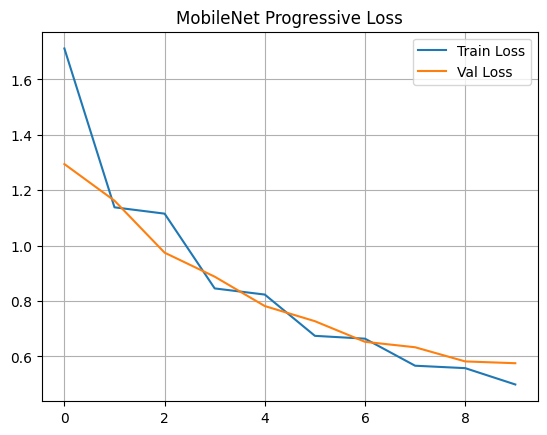

In [ ]:
plt.plot(loss_mob, label="Train Loss")
plt.plot(val_loss_mob, label="Val Loss")
plt.title("MobileNet Progressive Loss")
plt.legend()
plt.grid()
plt.show()

### PREDICTION

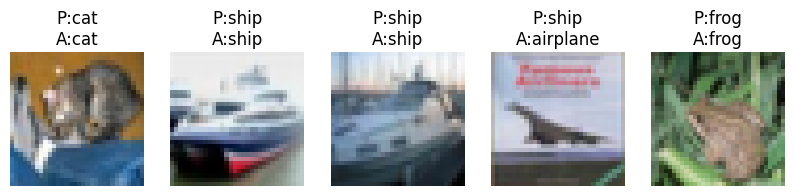

In [ ]:
images, labels = next(iter(testloader))
images = images.to(device)

outputs = model_mob(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    img = images[i].permute(1,2,0).numpy()
    plt.imshow(img)
    plt.title(f"P:{class_names[preds[i]]}\nA:{class_names[labels[i]]}")
    plt.axis("off")

plt.show()

## 2. EFFICIENT-NET

### MODEL

In [ ]:
model_eff = models.efficientnet_b0(weights="DEFAULT")
model_eff.classifier[1] = nn.Linear(1280, 10)
model_eff = model_eff.to(device)

optimizer_eff = optim.Adam(model_eff.parameters(), lr=0.001)

### TRAIN

In [35]:
loss_eff, acc_eff, val_loss_eff, val_acc_eff = train_progressive(
    model_eff, trainset, testloader, optimizer_eff,
    stages=stages, epochs_per_stage=2
)


--- Training with 10% data ---
Epoch 1: Train Acc=37.18% | Val Acc=49.90%
Epoch 2: Train Acc=57.70% | Val Acc=59.63%

--- Training with 25% data ---
Epoch 3: Train Acc=64.84% | Val Acc=69.40%
Epoch 4: Train Acc=73.59% | Val Acc=72.66%

--- Training with 50% data ---
Epoch 5: Train Acc=75.94% | Val Acc=76.51%
Epoch 6: Train Acc=80.58% | Val Acc=77.72%

--- Training with 75% data ---
Epoch 7: Train Acc=81.14% | Val Acc=80.77%
Epoch 8: Train Acc=83.99% | Val Acc=80.74%

--- Training with 100% data ---
Epoch 9: Train Acc=84.43% | Val Acc=83.07%
Epoch 10: Train Acc=86.63% | Val Acc=83.30%


### TEST ACCURACY

In [36]:
acc_eff_test = evaluate(model_eff, testloader)
print("EfficientNet Progressive Accuracy:", acc_eff_test)

EfficientNet Progressive Accuracy: 83.3


### ACCURACY GRAPH

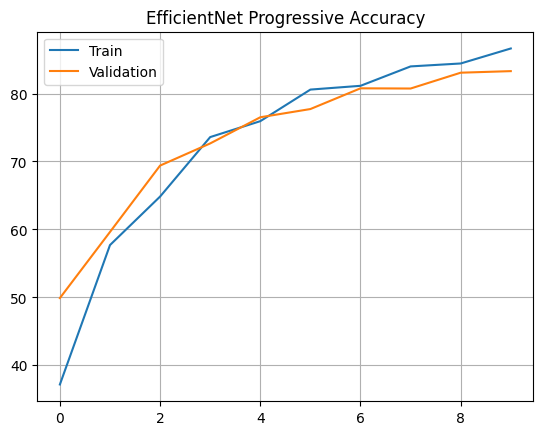

In [37]:
plt.plot(acc_eff, label="Train")
plt.plot(val_acc_eff, label="Validation")
plt.title("EfficientNet Progressive Accuracy")
plt.legend()
plt.grid()
plt.show()

### LOSS GRAPH

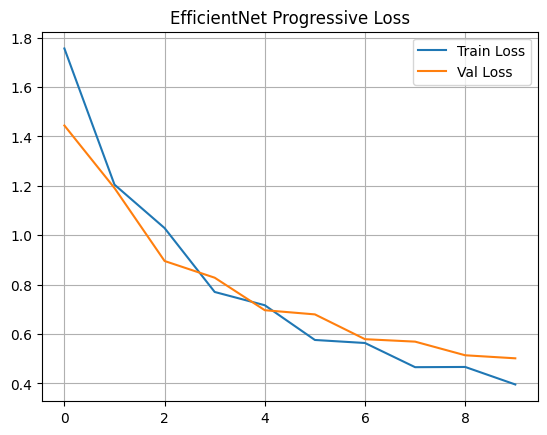

In [38]:
plt.plot(loss_eff, label="Train Loss")
plt.plot(val_loss_eff, label="Val Loss")
plt.title("EfficientNet Progressive Loss")
plt.legend()
plt.grid()
plt.show()

### PREDICTION

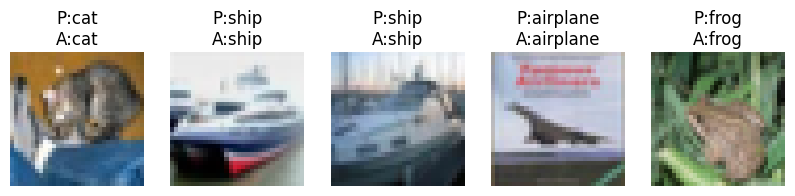

In [39]:
images, labels = next(iter(testloader))
images = images.to(device)

outputs = model_eff(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    img = images[i].permute(1,2,0).numpy()
    plt.imshow(img)
    plt.title(f"P:{class_names[preds[i]]}\nA:{class_names[labels[i]]}")
    plt.axis("off")

plt.show()

### FINAL ACCURACY

In [40]:
print("\nFinal Accuracy Comparison (Progressive Training)")

print(f"MobileNet Accuracy: {acc_mob_test:.2f}%")
print(f"EfficientNet Accuracy: {acc_eff_test:.2f}%")


Final Accuracy Comparison (Progressive Training)
MobileNet Accuracy: 80.65%
EfficientNet Accuracy: 83.30%


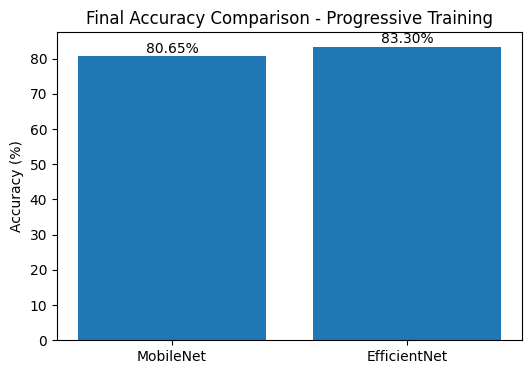

In [41]:
models = ['MobileNet', 'EfficientNet']
accuracies = [acc_mob_test, acc_eff_test]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.ylabel("Accuracy (%)")
plt.title("Final Accuracy Comparison - Progressive Training")

for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.show()

## Final Result Analysis (Progressive Training)

- EfficientNet achieved higher accuracy (83.30%) compared to MobileNet (80.65%).
- This is due to EfficientNet’s superior scaling and feature extraction capabilities.
- MobileNet performed well despite being a lightweight model.
- Progressive training improved performance significantly compared to earlier attempts.